In [ ]:
import numpy as np
import random
import itertools
import pandas as pd
import os
import ot
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from scipy.sparse import csr_matrix
from scipy.stats import pareto
from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans
from sklearn.decomposition import NMF
from sklearn.metrics.cluster import normalized_mutual_info_score as NMI
from EDRep_main.EDRep import NodeEmbedding  
from tqdm.notebook import tqdm

In [17]:
def generateSequence(outputfolder, model, args, n_graphs, start_idx=1, verbose=True, append_name='.csv'):
    for i in range(n_graphs):
        df = model(args)
        
        # Creiamo un indice progressivo con lo zero davanti (es. 01, 02... 10... 50)
        idx_str = str(start_idx + i).zfill(2)
        
        # Salviamo il file usando il nuovo indice
        df.to_csv(outputfolder + '/EL' + idx_str + append_name, index = False)

        if verbose:
            print("[%--25s] %d%%" % ('='*(int(i/(n_graphs)*25)) + '>', (i+1)/(n_graphs)*100), end='\r')
    return

In [3]:
def DCSBM(args):
    ''' 
    Function that generates a graph from the degree-corrected stochastic block model with
    n nodes and k communities
    
    Note that, with an appropriate choice of the parameters, this function can be used to
    generate an SBM or and ER random graph
    
    Use:
        edge_list = DCSBM(C,c, ℓ, θ, symmetric, make_connected)
    Inputs:
        args = C, c, ℓ, θ
            * C (array of size k x k) : affinity matrix of the network C
            * c (scalar) : average degree of the network
            * ℓ (array of size n) : vector containing the label of each node
            * θ  (array of size n) : vector with the intrinsic probability connection of each node
            * symmetric (bool): if True it returns an undirected graph
            * make_connected (bool): if True forces the graph to be connected adding edges
    
    Outputs:
        * edge_list (pandas dataframe) : edge list representation of the graph (ij)
        
    '''
    
    C, c, ℓ, θ, symmetric, make_connected  = args

    # number of communities
    k = len(np.unique(ℓ))
    
    # number of nodes
    n = len(θ)
    
    # (k x n) matrix where we store the value of the affinity wrt a given label for each node
    c_v = C[ℓ].T
    
    fs = list()
    ss = list()

    # we choose the nodes that should get connected wp = θ_i/n
    if symmetric:
        first = np.random.choice(n,int(n*c/2),p = θ/n)

    else:  
        first = np.random.choice(n,int(n*c),p = θ/n) 

    for i in range(k): 
        v = θ*c_v[i]
        
        # among the nodes of first, select those with label i
        first_selected = first[ℓ[first] == i]
        fs.append(first_selected.tolist())
        
        # choose the nodes to connect to the first_selected
        second_selected = np.random.choice(n,len(first_selected), p = v/np.sum(v))
        ss.append(second_selected.tolist())

    fs = list(itertools.chain(*fs))
    ss = list(itertools.chain(*ss))

    fs = np.array(fs)
    ss  = np.array(ss)


    # add nodes not appearing in the vector first, to ensure the graph is connected
    if make_connected:
        idx = np.arange(n)[np.logical_not(np.isin(np.arange(n), fs))]
        fs = np.concatenate([fs, idx])
        ss = np.concatenate([ss, np.argmax(θ)*np.ones(len(idx))])
    

    # create the edge list from the connection defined earlier
    edge_list = np.column_stack((fs,ss)) 
    
    # remove edges appearing more then once
    edge_list = np.unique(edge_list, axis = 0) 

    # replace self edges
    idx = edge_list[:,0] == edge_list[:,1]
    edge_list[:,1][idx] += 1
    idx = edge_list[:,1] == n
    edge_list[:,1][idx] = 0

    if symmetric:
        df = pd.DataFrame(columns = ['i', 'j'])
        M = np.maximum(edge_list[:,0], edge_list[:,1])
        m = np.minimum(edge_list[:,0], edge_list[:,1])
        df.i = np.concatenate([M, m])
        df.j = np.concatenate([m, M])

    else:
        df = pd.DataFrame(columns = ['i', 'j'])
        df.i = edge_list[:,0]
        df.j = edge_list[:,1]

    # add an edge to nodes with degree 0
    A = csr_matrix((np.ones(len(df)), (df.i, df.j)), shape = (n,n))
    d = A@np.ones(n)
    idx = d == 0


    return df


In [49]:
def GeometricModel(args):
    '''Generates an instance of a modified Geometric model from a given configuration of the points in space
    
    Use: A = GeometricModel(X, d, β)
    
    Inputs: args
        * X (array): coordinates of the points used to form edges
        * d (float): average degree
        * β (float): noise parameter
        
    Ouptput:
        * A (sparse csr_matrix): adjacency matrix of the generated graph'''


    X, d, β = args
    n = np.shape(X)[0]

    # compute the pairwise distance matrix
    no = (X**2)@np.ones(2)
    D = np.zeros((n,n))
    for i in range(n):
        D[i] += no
        D[:,i] += no

    D -= 2*X@X.T
    D = np.sqrt(np.abs(D))

    # compute the probability matrix
    P = np.exp(-β*D)
    P = P - np.diag(np.diag(P))
    p = P@np.ones(n)
    P = np.diag(p**(-1)).dot(P)
    
    # draw the edges
    idx1 = np.concatenate([np.ones(int(d/2))*i for i in range(n)])
    idx2 = np.concatenate([np.random.choice(np.arange(n), int(d/2), p = P[i], replace = False) for i in range(n)])

    df = pd.DataFrame(columns = ['i', 'j'])

    # symmetrize
    df.i = np.concatenate([idx1, idx2])
    df.j = np.concatenate([idx2, idx1])

    return df


In [4]:
def EmbDistance(X, Y, distance_type = 'unmatched'):
    '''This function computes the distance between 

    Use: d = EmbDistance(X, Y)

    Inputs:
        * X, Y (arrays): input embeddings corresponding to the two temporal graphs. The number of rows of the two matrices must be the same.
        
    Optional inputs:
        * distance_type (string): can be 'unmatched' or 'matched'

    Output:
        * d (float): distance between the two graphs.
    '''

    n1, d1 = X.shape
    n2, d2 = Y.shape

    # run initial checks

    if d1 != d2:
        raise DeprecationWarning('The embedding matrices have different dimensions')
    else:
        d = d1

    
    if distance_type not in ['unmatched', 'matched']:
        raise DeprecationWarning('The distance type is not valid')
    
    else:
        if (distance_type == 'matched') and (n1 != n2):
            raise DeprecationWarning("The input matrices do not have the same size")
        else:
            n = n1

    if distance_type == 'matched':
        Mxx = X.T@X
        Mxy = X.T@Y
        Myy = Y.T@Y
        d = np.sqrt(np.abs(np.linalg.norm(Mxx)**2 + np.linalg.norm(Myy)**2 - 2*np.linalg.norm(Mxy)**2))

    else:
        n1, n2 = X.shape[0], Y.shape[0]
        λ1 = np.linalg.eigvalsh(X.T@X)/n1
        λ2 = np.linalg.eigvalsh(Y.T@Y)/n2
        d = np.linalg.norm(λ1-λ2)
  
    return d

In [5]:
def get_adj(filepath):
    df = pd.read_csv(filepath)
    G = nx.from_pandas_edgelist(df, 'i', 'j')
    A = nx.adjacency_matrix(G).astype(float)

    return A

In [6]:
def node_embedding(g, dim_embedding,seed=42):
    rdn_state = np.random.get_state()
    random.seed(seed)
    np.random.seed(seed)
    embedding_a = NodeEmbedding(g, dim=dim_embedding, k=1, verbose=False)
    X_total = embedding_a.X
    np.random.set_state(rdn_state)
    return X_total


In [7]:
def w2_distance(emb_1, emb_2):
    S_1=emb_1@emb_1.T
    S_2=emb_2@emb_2.T
    vals_S_1=S_1.flatten()
    vals_S_2=S_2.flatten()
    wd2 = ot.wasserstein_1d(vals_S_1, vals_S_2, p=2)**(1/2)
    return wd2

In [8]:
def create_embeddings(path_files, dim):
    embeddings = []

    for file in tqdm(path_files, desc="Calcolando embeddings"):
        a = get_adj(file)
        emb = node_embedding(a, dim)
        embeddings.append(emb)
        
    return embeddings


In [9]:
def distances(embeddings, n):
    old_d = []
    new_d = []
    subset = embeddings[:n]
    
    k = len(subset)

    total_iters = k * (k - 1) // 2

    for a, b in tqdm(itertools.combinations(subset, 2), total=total_iters, desc="Calcolando distanze"):
        old = EmbDistance(a, b, 'unmatched')
        new = w2_distance(a, b)
        old_d.append(old)
        new_d.append(new)
 
    return old_d, new_d


In [10]:
def comparison_plot(old_d, new_d, name):
    plt.figure(figsize=(8, 6))

    plt.scatter(old_d, new_d,alpha=0.6)

    plt.xlabel("unmatched")
    plt.ylabel("wasserstein")
    plt.title(f"Comparing distances for {name}")
    plt.grid(True)
    plt.show()

In [11]:
def NMF_kmeans(M,k):

    n, _ = M.shape
    Mt = M + np.eye(n)*np.mean(M[M.nonzero()])
    Mt = Mt/np.mean(Mt)
    Y = NMF(n_components = k).fit(Mt).components_
    kmeans = KMeans(n_clusters = k, n_init = 10).fit(Y.T)
    return kmeans.labels_, np.abs(kmeans.score(Y.T))

def ClusterNMF(M, k):
    
    est_ℓ, score = NMF_kmeans(M, k)
    
    for i in range(20):
        est_ℓ_, score_ = NMF_kmeans(M, k)
        if score_ < score:
            score = score_
            est_ℓ = est_ℓ_
            
    return est_ℓ

In [ ]:
output_folder_dcsbm = os.path.join("data", "synthetic_graphs", "generated_dcsbm")
os.makedirs(output_folder_dcsbm, exist_ok=True)

output_folder_er = os.path.join("data", "synthetic_graphs", "generated_er")
os.makedirs(output_folder_er, exist_ok=True)

output_folder_conf = os.path.join("data", "synthetic_graphs", "generated_configuration")
os.makedirs(output_folder_conf, exist_ok=True)

output_folder_geo = os.path.join("data", "synthetic_graphs", "generated_geo")
os.makedirs(output_folder_geo, exist_ok=True)

In [13]:
#PARAMETRI CONDIVISI 
n_nodes = 1000
γ = 0.8 
symmetric = True
make_connected = True
c = 10 

# ER vs DCSBM

Calcolo c_in e c_out mantenendo c e k costanti, al variare di alpha.
   

In [15]:
def compute_cin_cout(c, k, alpha):
    c_out = c - alpha * np.sqrt(c)
    c_in = c + (k - 1) * alpha * np.sqrt(c)
    
    return c_in, c_out


In [ ]:
c_cost = 10 
k_cost = 4    

# range variazione di alpha
alpha_array = np.linspace(0, 2, 5)

c_in_array, c_out_array = compute_cin_cout(c_cost, k_cost, alpha_array)
print(c_in_array)
df_results = pd.DataFrame({
    'alpha': alpha_array,
    'c_in': c_in_array,
    'c_out': c_out_array
})

print(f"c = {c_cost}, k = {k_cost}\n")
print(df_results.to_string(index=False))


Generazione 15 grafi con DCSBM per ogni alpha = 0, 0.5, 1, 1.5, 2

In [ ]:
k = 3

θ_dcsbm = np.ones(n_nodes)
ℓ_dcsbm = np.zeros(n_nodes)
for i in range(k):
    ℓ_dcsbm[i*int(n_nodes/k): (i+1)*int(n_nodes/k)] = i
ℓ_dcsbm = ℓ_dcsbm.astype(int)

percorso_base_dcsbm = os.path.join("data", "synthetic_graphs", "generated_dcsbm")

for a in np.linspace(0, 2, 5):
    
    c_in, c_out = compute_cin_cout(c, k, a)
    C_dcsbm = np.ones((k,k)) * c_out
    C_dcsbm += np.diag(np.ones(k)) * (c_in - c_out)

    args_dcsbm = (C_dcsbm, c, ℓ_dcsbm, θ_dcsbm, symmetric, make_connected)
    
    cartella_corrente_dcsbm = os.path.join(percorso_base_dcsbm, f"alpha_{a:.2f}")
    os.makedirs(cartella_corrente_dcsbm, exist_ok=True)
    
    print(f"Grafi per alpha = {a:.2f} in: {cartella_corrente_dcsbm}")

    generateSequence(
        outputfolder=cartella_corrente_dcsbm, 
        model=DCSBM,             
        args=args_dcsbm,         
        n_graphs=15, 
        start_idx=1,                   
        verbose=True,
        append_name=".csv"               
    )
    
    print()

Generazione embedding 

In [137]:
embeddings_alpha_dcsbm= {}

for a in np.linspace(0, 2, 5):
    
    cartella_corrente_dcsbm = os.path.join(percorso_base_dcsbm, f"alpha_{a:.2f}")
    
    path_files_dcsbm = glob.glob(os.path.join(cartella_corrente_dcsbm, "*.csv"))
    
    path_files_dcsbm = sorted(path_files_dcsbm)
    
    print(f"Embedding per alpha = {a:.2f} ({len(path_files_dcsbm)} grafi)...")
    
    emb_list_dcsbm = create_embeddings(path_files_dcsbm, dim=32)
    
    embeddings_alpha_dcsbm[a] = emb_list_dcsbm


Embedding per alpha = 0.00 (15 grafi)...


Calcolando embeddings: 100%|██████████| 15/15 [00:02<00:00,  5.40it/s]


Embedding per alpha = 0.50 (15 grafi)...


Calcolando embeddings: 100%|██████████| 15/15 [00:02<00:00,  6.30it/s]


Embedding per alpha = 1.00 (15 grafi)...


Calcolando embeddings: 100%|██████████| 15/15 [00:02<00:00,  6.04it/s]


Embedding per alpha = 1.50 (15 grafi)...


Calcolando embeddings: 100%|██████████| 15/15 [00:02<00:00,  6.16it/s]


Embedding per alpha = 2.00 (15 grafi)...


Calcolando embeddings: 100%|██████████| 15/15 [00:02<00:00,  6.07it/s]


Scatter plot ER vs DCSMB

Calcolando distanze: 100%|██████████| 2775/2775 [19:14<00:00,  2.40it/s]


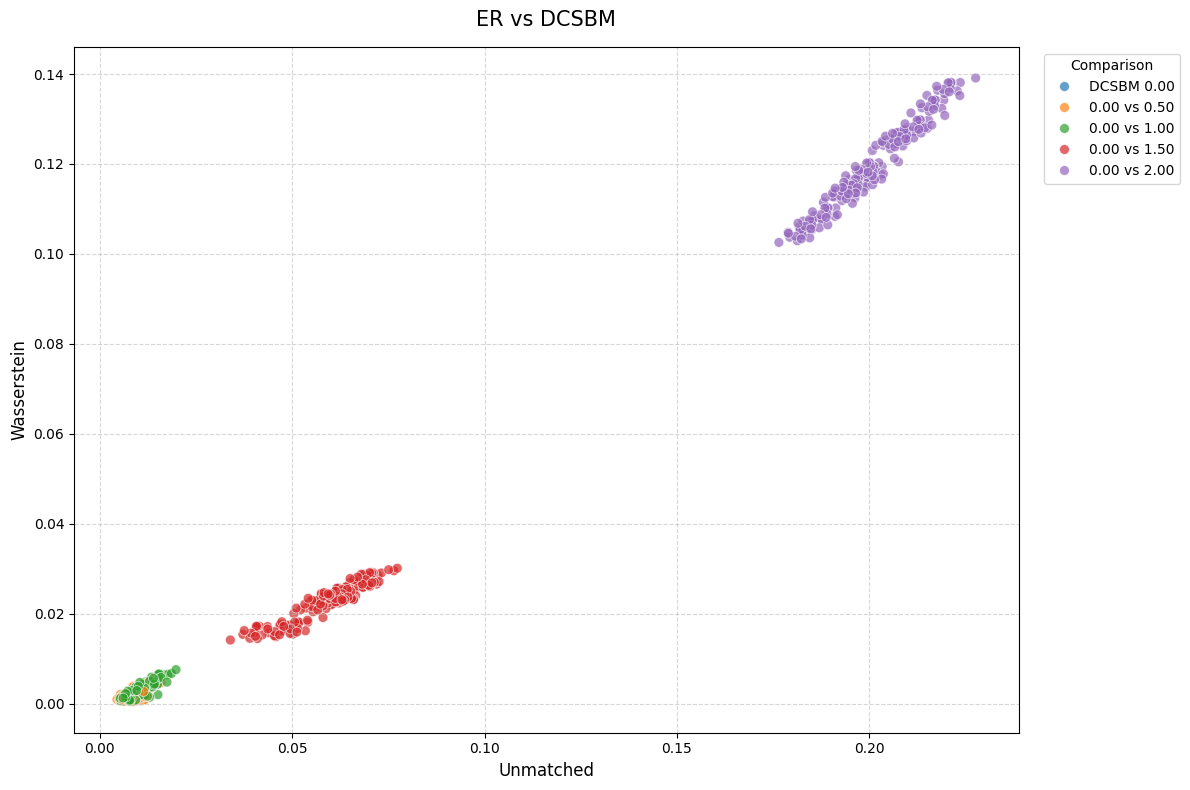

In [138]:
all_embeddings_dcsbm = []
labels_dcsbm = []

for a, emb_list_dcsbm in embeddings_alpha_dcsbm.items():
    for emb in emb_list_dcsbm:
        all_embeddings_dcsbm.append(emb)
        labels_dcsbm.append(a)

N = len(all_embeddings_dcsbm)

unmatched_dists_dcsbm = []
wasserstein_dists_dcsbm = []
categories_dcsbm = []

tot_combinazioni_dcsbm = N * (N - 1) // 2

for i, j in tqdm(itertools.combinations(range(N), 2), total=tot_combinazioni_dcsbm, desc="Calcolando distanze"):
    emb_i = all_embeddings_dcsbm[i]
    emb_j = all_embeddings_dcsbm[j]
    
    a_i = labels_dcsbm[i]
    a_j = labels_dcsbm[j]

    unmatched_dists_dcsbm.append(EmbDistance(emb_i, emb_j, 'unmatched'))
    wasserstein_dists_dcsbm.append(w2_distance(emb_i, emb_j))
    
    if a_i == a_j:
        categories_dcsbm.append(f"DCSBM {a_i:.2f}")
    else:
        a_min, a_max = sorted([a_i, a_j])
        categories_dcsbm.append(f"{a_min:.2f} vs {a_max:.2f}")

df_plot = pd.DataFrame({
    'Unmatched': unmatched_dists_dcsbm,
    'Wasserstein': wasserstein_dists_dcsbm,
    'Type': categories_dcsbm
})

categorie_da_mantenere_dcsbm = [
    "DCSBM 0.00",
    "0.00 vs 0.50",
    "0.00 vs 1.00",
    "0.00 vs 1.50",
    "0.00 vs 2.00"
]

df_plot_filtered = df_plot[df_plot['Type'].isin(categorie_da_mantenere_dcsbm)]

plt.figure(figsize=(12, 8)) 

sns.scatterplot(
    data=df_plot_filtered,  # Usa il DataFrame filtrato!
    x='Unmatched',
    y='Wasserstein',
    hue='Type',
    palette='tab10',        # Torniamo a tab10 visto che ora abbiamo solo 5 categorie
    alpha=0.7,
    s=50
)

plt.title("ER vs DCSBM", fontsize=15, pad=15)
plt.xlabel("Unmatched", fontsize=12)
plt.ylabel("Wasserstein", fontsize=12)

# Legenda
plt.legend(title="Comparison", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Calcolo NMI con ClusterNMF

In [140]:
D_old_dcsbm = squareform(unmatched_dists_dcsbm)
D_new_dcsbm = squareform(wasserstein_dists_dcsbm)

n_graphs_per_class_dcsbm = 15
n_classes_dcsbm = 5
 
ℓ_dcsbm= np.concatenate([[i for _ in range(n_graphs_per_class_dcsbm)] for i in range(n_classes_dcsbm)])
k_dcsbm = len(np.unique(ℓ_dcsbm)) 

score_old_dcsbm = NMI(ClusterNMF(D_old_dcsbm, k_dcsbm), ℓ_dcsbm)
score_new_dcsbm = NMI(ClusterNMF(D_new_dcsbm, k_dcsbm), ℓ_dcsbm)

print(f"Unmatched OLD (Unmatched): {score_old_dcsbm:.4f}")
print(f"Unmatched NEW (Wasserstein): {score_new_dcsbm:.4f}")

c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: 

Unmatched OLD (Unmatched): 0.6541
Unmatched NEW (Wasserstein): 0.6793


c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Grafici NMI

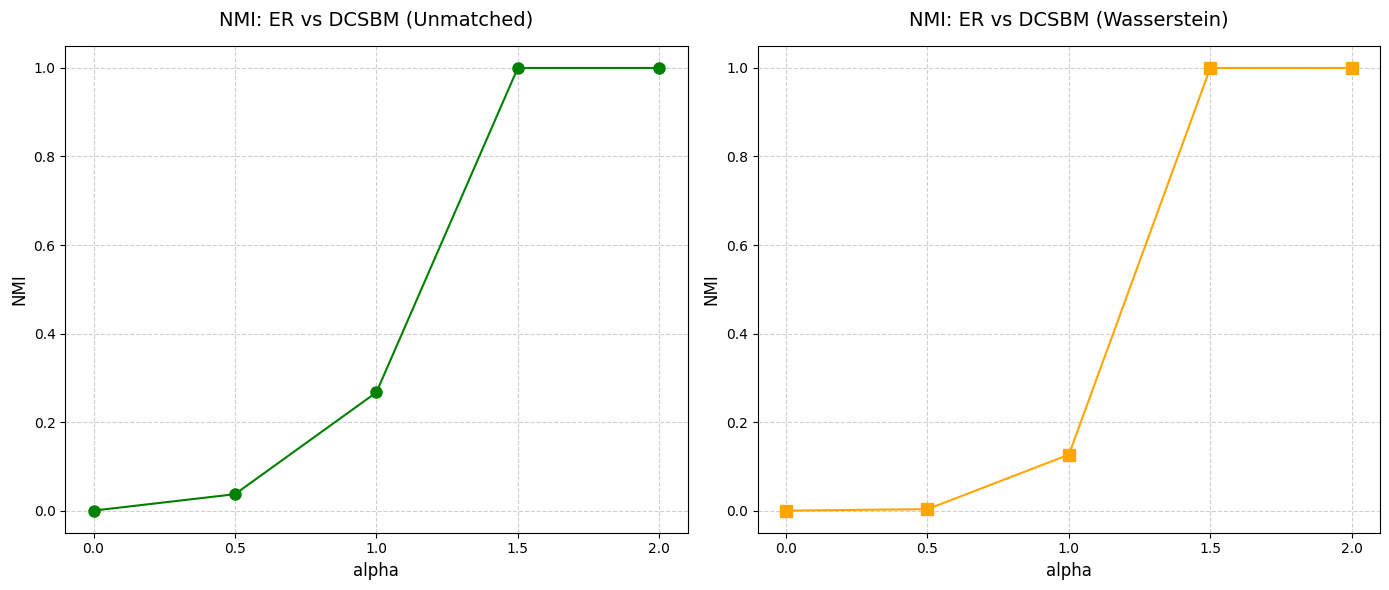

In [141]:
alphas_dcsbm = np.linspace(0, 2, 5)
n_graphs_per_class_dcsbm= 15

nmi_unmatched_dcsbm = []
nmi_wasserstein_dcsbm = []

# 2. Calcolo iterativo della NMI per ciascun alpha
for i, beta in enumerate(alphas_dcsbm):
    if i == 0:
        # Separare alpha=0 da alpha=0 non ha senso ai fini della classificazione.
        # Fissiamo la NMI a 0 come baseline.
        nmi_unmatched_dcsbm.append(0.0)
        nmi_wasserstein_dcsbm.append(0.0)
        continue
        
    # Creiamo gli indici: i primi 20 grafi (alpha=0.0) + i 20 grafi relativi all'alpha corrente
    idx = np.concatenate([np.arange(0, 15), np.arange(i*15, (i+1)*15)])
    
    # Estraiamo le sottomatrici 40x40 relative a questo subset
    D_old_sub = D_old_dcsbm[np.ix_(idx, idx)]
    D_new_sub = D_new_dcsbm[np.ix_(idx, idx)]
    
    # Creiamo le vere etichette (Ground Truth): 
    # 0 per la prima classe (alpha=0) e 1 per la seconda classe (alpha > 0)
    l_sub = np.concatenate([np.zeros(15), np.ones(15)])
    
    # Clustering a 2 classi sfruttando la tua funzione NMF
    est_l_old = ClusterNMF(D_old_sub, k=2)
    est_l_new = ClusterNMF(D_new_sub, k=2)
    
    # Calcolo dei punteggi NMI
    nmi_unmatched_dcsbm.append(NMI(est_l_old, l_sub))
    nmi_wasserstein_dcsbm.append(NMI(est_l_new, l_sub))

# 3. Plotting dei due grafici affiancati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: Distanza Unmatched
ax1.plot(alphas_dcsbm, nmi_unmatched_dcsbm, marker='o', linestyle='-', color='green', markersize=8)
ax1.set_title("NMI: ER vs DCSBM (Unmatched)", fontsize=14, pad=15)
ax1.set_xlabel("alpha", fontsize=12)
ax1.set_ylabel("NMI", fontsize=12)
ax1.set_xticks(alphas_dcsbm)
ax1.set_ylim(-0.05, 1.05)
ax1.grid(True, linestyle='--', alpha=0.6)

# Grafico 2: Distanza Wasserstein
ax2.plot(alphas_dcsbm, nmi_wasserstein_dcsbm, marker='s', linestyle='-', color='orange', markersize=8)
ax2.set_title("NMI: ER vs DCSBM (Wasserstein)", fontsize=14, pad=15)
ax2.set_xlabel("alpha", fontsize=12)
ax2.set_ylabel("NMI", fontsize=12)
ax2.set_xticks(alphas_dcsbm)
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, linestyle='--', alpha=0.6)

# Aggiusta il layout per evitare sovrapposizioni
plt.tight_layout()
plt.show()

# ER vs GM


In [ ]:
output_folder_geo = os.path.join("data", "synthetic_graphs", "generated_geo", "geo")

for beta in range(0, 21, 5):

    n_geo = np.random.randint(int(n_nodes*(1-γ)), int(n_nodes*(1+γ)))
    
    r_geo = np.random.uniform(0, 1, n_geo)
    θ_geo = np.random.uniform(0, 2*np.pi, n_geo)
    X = np.zeros((n_geo, 2))
    X[:,0] = r_geo*np.cos(θ_geo)
    X[:,1] = r_geo*np.sin(θ_geo)

    args_geo = (X, c, beta)

    current_output_folder_geo = f"{output_folder_geo}_beta_{beta}"
    os.makedirs(current_output_folder_geo, exist_ok=True)

    generateSequence(
        outputfolder=current_output_folder_geo, 
        model=GeometricModel,             
        args=args_geo,         
        n_graphs=10,           
        verbose=True             
    )

In [ ]:

embeddings_per_beta = {}

for beta in range(0, 21, 5):
    
    cartella_corrente_geo = f"{output_folder_geo}_beta_{beta}"
    
    path_files_geo = glob.glob(os.path.join(cartella_corrente_geo, "*.csv"))
    path_files_geo = sorted(path_files_geo)
    
    print(f"Embedding per beta = {beta} ({len(path_files_geo)} grafi, da {cartella_corrente_geo})...")
    
    if len(path_files_geo) == 0:
        print("ATTENZIONE: Nessun file trovato in questa cartella!")
        continue
        
    emb_list_geo = create_embeddings(path_files_geo, dim=32)
    embeddings_per_beta[beta] = emb_list_geo

Calcolando distanze: 100%|██████████| 1225/1225 [05:34<00:00,  3.66it/s]


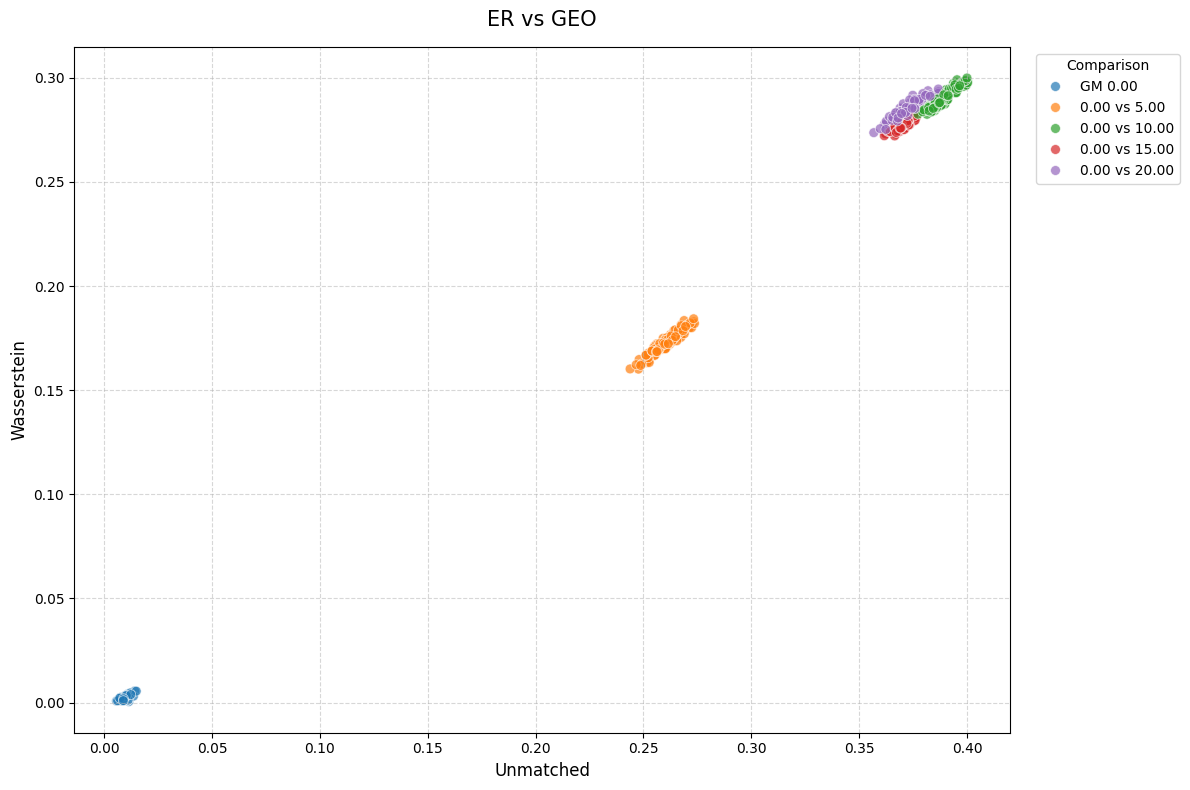

In [ ]:
all_embeddings_geo = []
labels_geo = []

for beta, emb_list_geo in embeddings_per_beta.items():
    for emb in emb_list_geo:
        all_embeddings_geo.append(emb)
        labels_geo.append(beta)
        
N = len(all_embeddings_geo)

tot_combinazioni_geo = N * (N - 1) // 2
unmatched_dists_geo = []
wasserstein_dists_geo = []
categories_geo = []

for i, j in tqdm(itertools.combinations(range(N), 2), total=tot_combinazioni_geo, desc="Calcolando distanze"):
    beta_i = labels_geo[i]
    beta_j = labels_geo[j]
   
    emb_i = all_embeddings_geo[i]
    emb_j = all_embeddings_geo[j]
    
    unmatched_dists_geo.append(EmbDistance(emb_i, emb_j, 'unmatched'))
    wasserstein_dists_geo.append(w2_distance(emb_i, emb_j))
  
    if beta_i == beta_j:
        categories_geo.append(f"GM {beta_i:.2f}")
    else:
        beta_min, beta_max = sorted([beta_i, beta_j])
        categories_geo.append(f"{beta_min:.2f} vs {beta_max:.2f}")
    

df_plot = pd.DataFrame({
    'Unmatched': unmatched_dists_geo,
    'Wasserstein': wasserstein_dists_geo,
    'Type': categories_geo
})

plt.figure(figsize=(12, 8)) 

categories_geo_keep = [
    "GM 0.00", 
    "0.00 vs 5.00", 
    "0.00 vs 10.00", 
    "0.00 vs 15.00", 
    "0.00 vs 20.00"
]

df_plot_filtered = df_plot[df_plot['Type'].isin(categories_geo_keep)]

sns.scatterplot(
    data=df_plot_filtered, 
    x='Unmatched',
    y='Wasserstein',
    hue='Type',
    hue_order=categories_geo_keep, 
    palette='tab10',            
    alpha=0.7,
    s=50
)

plt.title("ER vs GEO", fontsize=15, pad=15)
plt.xlabel("Unmatched", fontsize=12)
plt.ylabel("Wasserstein", fontsize=12)

plt.legend(title="Comparison", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: 

Unmatched OLD (Unmatched): 0.8277
Unmatched NEW (Wasserstein): 1.0000


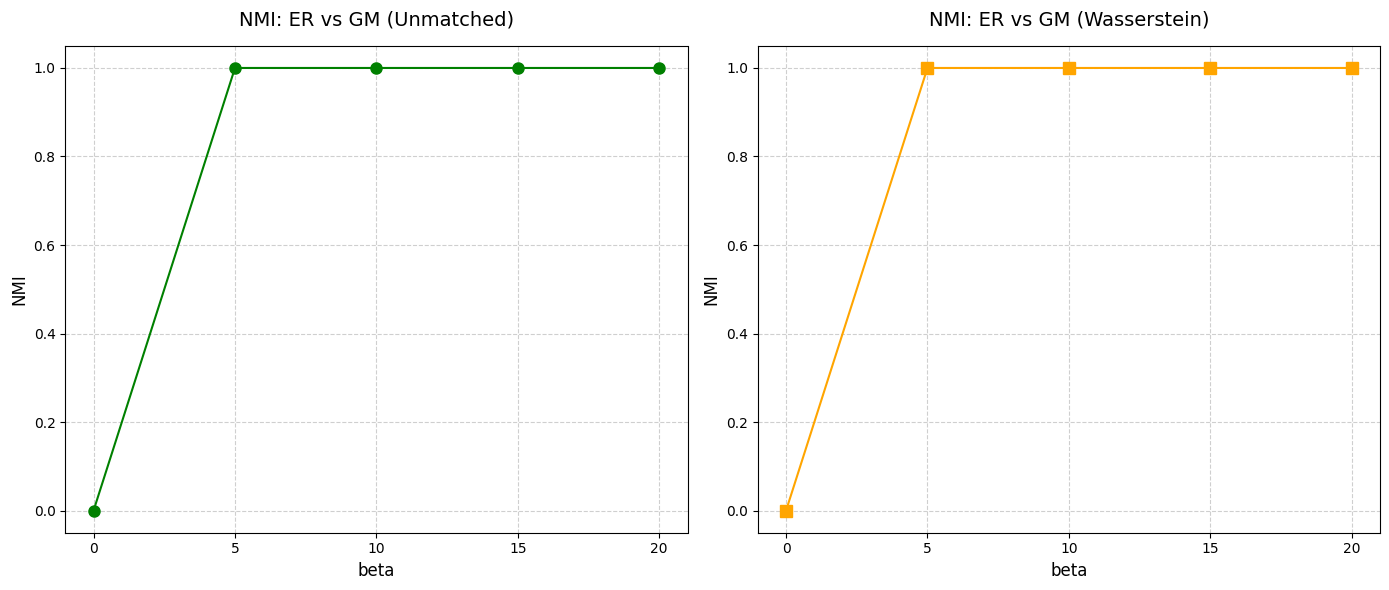

In [148]:


D_old_geo = squareform(unmatched_dists_geo)
D_new_geo = squareform(wasserstein_dists_geo)
n_graphs_per_class_geo = 10
n_classes_geo = 5
 
ℓ_geo = np.concatenate([[i for _ in range(n_graphs_per_class_geo)] for i in range(n_classes_geo)])
k_geo = len(np.unique(ℓ_geo)) 

score_old_geo = NMI(ClusterNMF(D_old_geo, k_geo), ℓ_geo)
score_new_geo = NMI(ClusterNMF(D_new_geo, k_geo), ℓ_geo)

print(f"Unmatched OLD (Unmatched): {score_old_geo:.4f}")
print(f"Unmatched NEW (Wasserstein): {score_new_geo:.4f}")

betas = np.linspace(0, 20, 5)

nmi_unmatched_geo = []
nmi_wasserstein_geo = []

# 2. Calcolo iterativo della NMI per ciascun alpha
for i, beta in enumerate(betas):
    if i == 0:
        # Separare alpha=0 da alpha=0 non ha senso ai fini della classificazione.
        # Fissiamo la NMI a 0 come baseline.
        nmi_unmatched_geo.append(0.0)
        nmi_wasserstein_geo.append(0.0)
        continue
        
    # Creiamo gli indici: i primi 20 grafi (alpha=0.0) + i 20 grafi relativi all'alpha corrente
    idx = np.concatenate([np.arange(0, 10), np.arange(i*10, (i+1)*10)])
    
    # Estraiamo le sottomatrici 40x40 relative a questo subset
    D_old_sub = D_old_geo[np.ix_(idx, idx)]
    D_new_sub = D_new_geo[np.ix_(idx, idx)]
    
    # Creiamo le vere etichette (Ground Truth): 
    # 0 per la prima classe (alpha=0) e 1 per la seconda classe (alpha > 0)
    l_sub = np.concatenate([np.zeros(10), np.ones(10)])
    
    # Clustering a 2 classi sfruttando la tua funzione NMF
    est_l_old = ClusterNMF(D_old_sub, k=2)
    est_l_new = ClusterNMF(D_new_sub, k=2)
    
    # Calcolo dei punteggi NMI
    nmi_unmatched_geo.append(NMI(est_l_old, l_sub))
    nmi_wasserstein_geo.append(NMI(est_l_new, l_sub))

# 3. Plotting dei due grafici affiancati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: Distanza Unmatched
ax1.plot(betas, nmi_unmatched_geo, marker='o', linestyle='-', color='green', markersize=8)
ax1.set_title("NMI: ER vs GM (Unmatched)", fontsize=14, pad=15)
ax1.set_xlabel("beta", fontsize=12)
ax1.set_ylabel("NMI", fontsize=12)
ax1.set_xticks(betas)
ax1.set_ylim(-0.05, 1.05)
ax1.grid(True, linestyle='--', alpha=0.6)

# Grafico 2: Distanza Wasserstein
ax2.plot(betas, nmi_wasserstein_geo, marker='s', linestyle='-', color='orange', markersize=8)
ax2.set_title("NMI: ER vs GM (Wasserstein)", fontsize=14, pad=15)
ax2.set_xlabel("beta", fontsize=12)
ax2.set_ylabel("NMI", fontsize=12)
ax2.set_xticks(betas)
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, linestyle='--', alpha=0.6)

# Aggiusta il layout per evitare sovrapposizioni
plt.tight_layout()
plt.show()